<!-- WARNING: THIS FILE WAS AUTOGENERATED! DO NOT EDIT! -->

```
Input: Tleaf, APAR, gs, gbc, gbv, atmospheric conditions
                    │
                    ▼
    ┌──────────────────────────────────────┐
    │  STEP 1: Temperature adjustment      │
    │                                      │
    │  C3 plants:                          │
    │    Kc, Ko, Γ* ← Arrhenius only       │  ← Eq. 11.34
    │    Vcmax ← peaked Arrhenius          │  ← Eq. 11.35 + 11.36
    │    Jmax  ← peaked Arrhenius          │  ← Eq. 11.35 + 11.36
    │    Rd    ← peaked Arrhenius          │  ← Eq. 11.35 + 11.36
    │                                      │
    │  C4 plants:                          │
    │    Vcmax ← Q10 + stress factors      │  ← Eq. 11.72
    │    Rd    ← Q10 + high-T stress       │  ← Eq. 11.73
    │    kp    ← Q10 only                  │  ← Eq. 11.74
    └──────────────────────────────────────┘
                    │
                    ▼
    ┌──────────────────────────────────────┐
    │  STEP 2: Electron transport (C3)     │
    │                                      │
    │  I_PSII = 0.5 · Φ_PSII · APAR        │  ← Eq. 11.23
    │  Solve: Θ_J·J² - (I+Jmax)J           │
    │         + I·Jmax = 0                 │  ← Eq. 11.21
    │  J = smaller root                    │  ← Eq. 11.24
    └──────────────────────────────────────┘
                    │
                    ▼
    ┌──────────────────────────────────────┐
    │  STEP 3: Photosynthesis & Ci         │
    │  → ci_func_optimization()            │  ← Eq. 11.78
    │    Returns: Ac, Aj, Ap, Ag, An,      │
    │             cs, ci                   │
    └──────────────────────────────────────┘
                    │
                    ▼
    ┌──────────────────────────────────────┐
    │  STEP 4: Surface humidity & VPD      │
    │  hs = weighted avg of eair & esat    │
    │  vpd = esat - hs·esat                │
    └──────────────────────────────────────┘
                    │
                    ▼
    ┌──────────────────────────────────────┐
    │  STEP 5: Error check                 │
    │  An from biochemistry must match     │
    │  An from diffusion (Eq. 11.75)       │
    └──────────────────────────────────────┘
                    │
                    ▼
                 Return flux
```

In [0]:
#| echo: false
#| output: asis
show_doc(leaf_photosynthesis)

---

[source](https://github.com/ecamo19/plant_hydraulics/blob/main/plant_hydraulics/leaf_photosynthesis.py#L13){target="_blank" style="float:right; font-size:smaller"}

### leaf_photosynthesis

```python

def leaf_photosynthesis(
    physcon:PhysCon, # Physical constants:
- tfrz : float
    Freezing point of water (K).
- rgas : float
    Universal gas constant (J/K/mol).
    atmos:Atmos, # Atmospheric forcing variables:
- co2air : float
    Atmospheric CO2 concentration (umol/mol).
- eair : float
    Vapor pressure of air (Pa).
    leaf:Leaf, # Leaf physiological parameters:

Photosynthetic pathway and co-limitation:
- c3psn : int
    Photosynthetic pathway: 1 = C3, 0 = C4 plant.

Rates at 25°C:
- vcmax25 : float
    Maximum carboxylation rate at 25°C (umol/m2/s).
- jmax25 : float
    Maximum electron transport rate at 25°C (umol/m2/s).
- rd25 : float
    Leaf respiration rate at 25°C (umol CO2/m2/s).

Michaelis-Menten constants at 25°C:
- kc25 : float
    Michaelis-Menten constant for CO2 at 25°C (umol/mol).
- ko25 : float
    Michaelis-Menten constant for O2 at 25°C (mmol/mol).
- cp25 : float
    CO2 compensation point at 25°C (umol/mol).

Activation energies (J/mol):
- kcha, koha, cpha : float
    Activation energies for Kc, Ko, and Γ* respectively.
- vcmaxha, jmaxha, rdha : float
    Activation energies for Vcmax, Jmax, and Rd respectively.

Deactivation energies (J/mol):
- vcmaxhd, jmaxhd, rdhd : float
    Deactivation energies for Vcmax, Jmax, and Rd respectively.

Entropy terms (J/mol/K):
- vcmaxse, jmaxse, rdse : float
    Entropy terms for Vcmax, Jmax, and Rd respectively.

Scaling factors for high temperature inhibition (1.0 at 25°C):
- vcmaxc, jmaxc, rdc : float
    Scaling factors for Vcmax, Jmax, and Rd respectively.

Electron transport:
- phi_psii : float
    Quantum yield of photosystem II (mol/mol).
- theta_j : float
    Empirical curvature parameter for electron transport rate (-).

C4-specific:
- kp25_c4 : float
    Initial slope of CO2 response curve at 25°C (mol/m2/s).
    flux:Flux, # Flux variables with the following inputs:
- gbv : float
    Leaf boundary layer conductance for H2O (mol H2O/m2 leaf/s).
- gbc : float
    Leaf boundary layer conductance for CO2 (mol CO2/m2 leaf/s).
- apar : float
    Leaf absorbed PAR (umol photon/m2 leaf/s).
- tleaf : float
    Leaf temperature (K).
- gs : float
    Leaf stomatal conductance (mol H2O/m2 leaf/s).
)->Flux: # Updated flux object with the following attributes:

Temperature-adjusted parameters:
- vcmax : float
    Maximum carboxylation rate (umol/m2/s).
- jmax : float
    Maximum electron transport rate (umol/m2/s).
- cp : float
    CO2 compensation point (umol/mol).
- kc : float
    Michaelis-Menten constant for CO2 (umol/mol).
- ko : float
    Michaelis-Menten constant for O2 (mmol/mol).
- je : float
    Electron transport rate (umol/m2/s).
- kp_c4 : float
    C4 initial slope of CO2 response curve (mol/m2/s).
- rd : float
    Leaf respiration rate (umol CO2/m2 leaf/s).

Photosynthetic rates:
- ac : float
    Rubisco-limited gross photosynthesis (umol CO2/m2 leaf/s).
- aj : float
    RuBP regeneration-limited gross photosynthesis
    (umol CO2/m2 leaf/s).
- ap : float
    Product-limited (C3) or CO2-limited (C4) gross
    photosynthesis (umol CO2/m2 leaf/s).
- ag : float
    Leaf gross photosynthesis (umol CO2/m2 leaf/s).
- an : float
    Leaf net photosynthesis (umol CO2/m2 leaf/s).

Leaf surface gas exchange:
- cs : float
    Leaf surface CO2 concentration (umol/mol).
- ci : float
    Leaf intercellular CO2 concentration (umol/mol).
- hs : float
    Leaf fractional humidity at surface (-).
- vpd : float
    Leaf vapor pressure deficit at surface (Pa).


```

*Calculate leaf photosynthesis for a specified stomatal conductance.*

Temperature-adjust photosynthetic parameters using the Arrhenius function
(Equation 11.34) and peaked Arrhenius function (Equations 11.35–11.36),
calculate the electron transport rate (Equation 11.21), then compute
gross and net photosynthesis and intercellular CO2 via
`[`leaf_ci_optimization`](https://ecamo19.github.io/plant_hydraulics/leaf_ci_optimization.html#leaf_ci_optimization)`. This routine is used with the water-use
efficiency (WUE) stomatal optimization.

For C3 plants, temperature adjustment uses the Arrhenius function
(Equation 11.34) for Kc, Ko, and Γ*, and the peaked Arrhenius
function (Equations 11.35–11.36) for Vcmax, Jmax, and Rd. The
electron transport rate J is the smaller root of the co-limitation
quadratic (Equation 11.21) between the light utilization rate
I_PSII = 0.5 · Φ_PSII · APAR and Jmax.

For C4 plants, temperature adjustment follows the Q10 formulation
with high- and low-temperature stress factors (Equations 11.72–11.74).

After temperature adjustment, `[`leaf_ci_optimization`](https://ecamo19.github.io/plant_hydraulics/leaf_ci_optimization.html#leaf_ci_optimization)` is called to
compute photosynthetic rates and intercellular CO2.

__Parameters:__

- PhysCon: Physical constants:

    - tfrz: Freezing point of water (K).
    - rgas: Universal gas constant (J/K/mol).

 - Atmos: Atmospheric forcing variables:

    - co2air: Atmospheric CO2 concentration (umol/mol).
    - eair: Vapor pressure of air (Pa).

 - Leaf: Leaf physiological parameters:

    - Photosynthetic pathway and co-limitation:

        - c3psn: Photosynthetic pathway: 1 = C3, 0 = C4 plant.

    - Rates at 25°C:

        - vcmax25: Maximum carboxylation rate at 25°C (umol/m2/s).
        - jmax25: Maximum electron transport rate at 25°C (umol/m2/s).
        - rd25: Leaf respiration rate at 25°C (umol CO2/m2/s).

    - Michaelis-Menten constants at 25°C:

        - kc25: Michaelis-Menten constant for CO2 at 25°C (umol/mol).
        - ko25: Michaelis-Menten constant for O2 at 25°C (mmol/mol).
        - cp25: CO2 compensation point at 25°C (umol/mol).

    - Activation energies (J/mol):

        - kcha, koha, cpha: Activation energies for Kc, Ko, and Γ* respectively.
        - vcmaxha, jmaxha, rdha: Activation energies for Vcmax, Jmax, and Rd respectively.

    - Deactivation energies (J/mol):
        - vcmaxhd, jmaxhd, rdhd: Deactivation energies for Vcmax, Jmax, and Rd respectively.

    - Entropy terms (J/mol/K):
        - vcmaxse, jmaxse, rdse: Entropy terms for Vcmax, Jmax, and Rd respectively.

    - Scaling factors for high temperature inhibition (1.0 at 25°C):
        - vcmaxc, jmaxc, rdc: Scaling factors for Vcmax, Jmax, and Rd respectively.

    - Electron transport:
        - phi_psii: Quantum yield of photosystem II (mol/mol).
        - theta_j: Empirical curvature parameter for electron transport rate (-).

    - C4-specific:
        - kp25_c4: Initial slope of CO2 response curve at 25°C (mol/m2/s).

- Flux: Flux variables with the following inputs:

    - gbv: Leaf boundary layer conductance for H2O (mol H2O/m2 leaf/s).
    - gbc: Leaf boundary layer conductance for CO2 (mol CO2/m2 leaf/s).
    - apar: Leaf absorbed PAR (umol photon/m2 leaf/s).
    - tleaf: Leaf temperature (K).
    - gs: Leaf stomatal conductance (mol H2O/m2 leaf/s).

__Returns:__

- Flux: Updated flux object with the following attributes:

    - Temperature-adjusted parameters:

        - vcmax: Maximum carboxylation rate (umol/m2/s).
        - jmax: Maximum electron transport rate (umol/m2/s).
        - cp: CO2 compensation point (umol/mol).
        - kc: Michaelis-Menten constant for CO2 (umol/mol).
        - ko: Michaelis-Menten constant for O2 (mmol/mol).
        - je: Electron transport rate (umol/m2/s).
        - kp_c4: C4 initial slope of CO2 response curve (mol/m2/s).
        - rd: Leaf respiration rate (umol CO2/m2 leaf/s).

    - Photosynthetic rates:

        - ac: Rubisco-limited gross photosynthesis (umol CO2/m2 leaf/s).
        - aj: RuBP regeneration-limited gross photosynthesis (umol CO2/m2 leaf/s).
        - ap: Product-limited (C3) or CO2-limited (C4) gross photosynthesis (umol CO2/m2 leaf/s).
        - ag: Leaf gross photosynthesis (umol CO2/m2 leaf/s).
        - an: Leaf net photosynthesis (umol CO2/m2 leaf/s).

    - Leaf surface gas exchange:

        - cs: Leaf surface CO2 concentration (umol/mol).
        - ci: Leaf intercellular CO2 concentration (umol/mol).
        - hs: Leaf fractional humidity at surface (-).
        - vpd: Leaf vapor pressure deficit at surface (Pa).

### Example leaf_photosynthesis() 

This example reproduces figure 11.9 of the book

In [ ]:
import copy
import numpy as np
import matplotlib.pyplot as plt
from plant_hydraulics.leaf_phys_params import leaf_phys_params
from plant_hydraulics.parameter_classes import Params, PhysCon, Atmos, Leaf, Flux

#### Initialize base objects

In [ ]:
params = Params()
physcon = PhysCon()

# Base atmospheric conditions (these don't matter much for the
# temperature response — we just need valid values)
atmos = Atmos()

atmos.patm = 101325.0

# umol/mol
atmos.co2air = 380.0

# mmol/mol
atmos.o2air = 209.0

# K (placeholder)
atmos.tair = 25.0 + physcon.tfrz

# Pa (placeholder)
atmos.eair = 1500.0
atmos.rhomol = atmos.patm / (physcon.rgas * atmos.tair)

# J/mol/K
atmos.cpair = 29.2

# Base leaf — start from standard C3 parameters
leaf_base = Leaf()
leaf_base.c3psn = 1
leaf_base = leaf_phys_params(params, physcon, leaf_base)

#### Apply Kattge & Knorr (2007) temperature acclimation.

Modifies ΔHa, ΔHd, ΔS for Vcmax and Jmax, and adjusts the Jmax25/Vcmax25 ratio 
for a given growth temperature TA (°C).

In [ ]:
def apply_kattge_knorr_acclimation(leaf, physcon, growth_temp):
    leaf = copy.deepcopy(leaf)

    # Activation energies (Kattge & Knorr values)

    # J/mol (different from Bernacchi's 65330)
    leaf.vcmaxha = 72000.0

    # J/mol (different from Bernacchi's 43540)
    leaf.jmaxha = 50000.0

    # Deactivation energy (same for both J/mol)
    leaf.vcmaxhd = 200000.0
    leaf.jmaxhd = 200000.0

    # Entropy terms vary with growth temperature
    # Equation 11.62: ΔS_vcmax = 668.39 - 1.07 * TA
    # J/mol/K
    leaf.vcmaxse = 668.39 - 1.07 * growth_temp

    # Equation 11.63: ΔS_jmax = 659.70 - 0.75 * TA
    # J/mol/K
    leaf.jmaxse = 659.70 - 0.75 * growth_temp

    # Jmax25/Vcmax25 ratio varies with growth temperature
    # Equation 11.64: Jmax25/Vcmax25 = 2.59 - 0.035 * TA
    ratio = 2.59 - 0.035 * growth_temp
    leaf.jmax25 = ratio * leaf.vcmax25

    # Recalculate the fth25 scaling factors (fc) for the new
    #   ΔHd and ΔS values. This ensures fH(T) = 1.0 at 25°C.
    T25 = physcon.tfrz + 25.0
    leaf.vcmaxc = 1.0 + np.exp(
        (-leaf.vcmaxhd + leaf.vcmaxse * T25) / (physcon.rgas * T25)
    )
    leaf.jmaxc = 1.0 + np.exp((-leaf.jmaxhd + leaf.jmaxse * T25) / (physcon.rgas * T25))

    return leaf

In [ ]:
# Leaf temperatures (°C)
leaf_temperatures = np.linspace(0, 50, 101)

In [ ]:
# Growth temperatures (°C)
growth_temps = [15.0, 25.0, 35.0]

In [ ]:
# Plot colors and labels
colors = ["blue", "green", "red"]
labels = ["15°C", "25°C", "35°C"]

In [ ]:
# Storage for results

# {TA: array of Ac values}
Ac_results = {}

# {TA: array of Aj values}
Aj_results = {}

In [ ]:
# For each growth temperature (15, 25, 35°C):
for each_growth_temp in growth_temps:
    # 1. Apply Kattge & Knorr acclimation to modify leaf parameters
    # Apply acclimation for this growth temperature
    leaf_accl = apply_kattge_knorr_acclimation(leaf_base, physcon, each_growth_temp)

    Ac_arr = np.zeros_like(leaf_temperatures)
    Aj_arr = np.zeros_like(leaf_temperatures)

    # 2. Loop over leaf temperatures from 0 to 50°C
    for each_i, each_temp in enumerate(leaf_temperatures):
        # Create fresh flux object for each temperature
        flux = Flux()

        # Leaf temperature (K)
        flux.tleaf = each_temp + physcon.tfrz

        # Saturating light (absorbed PAR)
        flux.apar = 2000.0 * 0.8

        # Stomatal conductance (mol H2O/m2/s)
        flux.gs = 0.4

        # Compute boundary layer conductances
        # Use a representative wind speed → large gbh so boundary layer
        # doesn't dominate. We care about the temperature response, not
        # the boundary layer effect.

        # mol/m2/s (large = well-ventilated)
        flux.gbh = 5.0

        # gbv = 1.10 * gbh
        flux.gbv = 5.0 * 1.10

        # gbc = gbh / 1.4
        flux.gbc = 5.0 / 1.40

        # 3. Call leaf_photosynthesis() at each temperature
        flux = leaf_photosynthesis(physcon, atmos, leaf_accl, flux)

        # 4. Record Ac (Rubisco-limited) and Aj (light-limited)

        # Net Ac-limited rate
        Ac_arr[each_i] = flux.ac - flux.rd

        # Net Aj-limited rate
        Aj_arr[each_i] = flux.aj - flux.rd

    Ac_results[each_growth_temp] = Ac_arr
    Aj_results[each_growth_temp] = Aj_arr

#### Compute respiration curves 

In [ ]:
# Basal respiration at T0 (umol/m2/s) — from Figure 11.9 caption
Rd0 = 0.9

# Reference temperature (°C)
T0 = 25.0

In [ ]:
# Equation 11.65: Rd = Rd0 * Q10^((T-T0)/10)
Rd_constant_Q10 = Rd0 * 2.0 ** ((leaf_temperatures - T0) / 10.0)

In [ ]:
# Equation 11.66: Q10 = 3.22 - 0.046*T
Q10_variable = 3.22 - 0.046 * leaf_temperatures

In [ ]:
# Equation 11.65 with variable Q10:
# Must integrate the variable Q10 properly. The instantaneous Q10
# changes with temperature, so Rd at temperature T is computed by
# applying the Q10 at each temperature step.
# For the Tjoelker formulation, Rd = Rd0 * Q10(T)^((T-T0)/10)
Rd_variable_Q10 = Rd0 * Q10_variable ** ((leaf_temperatures - T0) / 10.0)

In [ ]:
# Variable Q10 + basal rate acclimation (Atkin et al. 2008)
# Equation 11.67: Rd = 10^(-0.00794*(TA-T0)) * Rd0 * Q10(T)^((T-T0)/10)
Rd_acclimated = {}
for each_temp in growth_temps:
    basal_adjustment = 10.0 ** (-0.00794 * (each_temp - T0))
    Rd_acclimated[each_temp] = (
        basal_adjustment * Rd0 * Q10_variable ** ((leaf_temperatures - T0) / 10.0)
    )

#### Figure 11.9

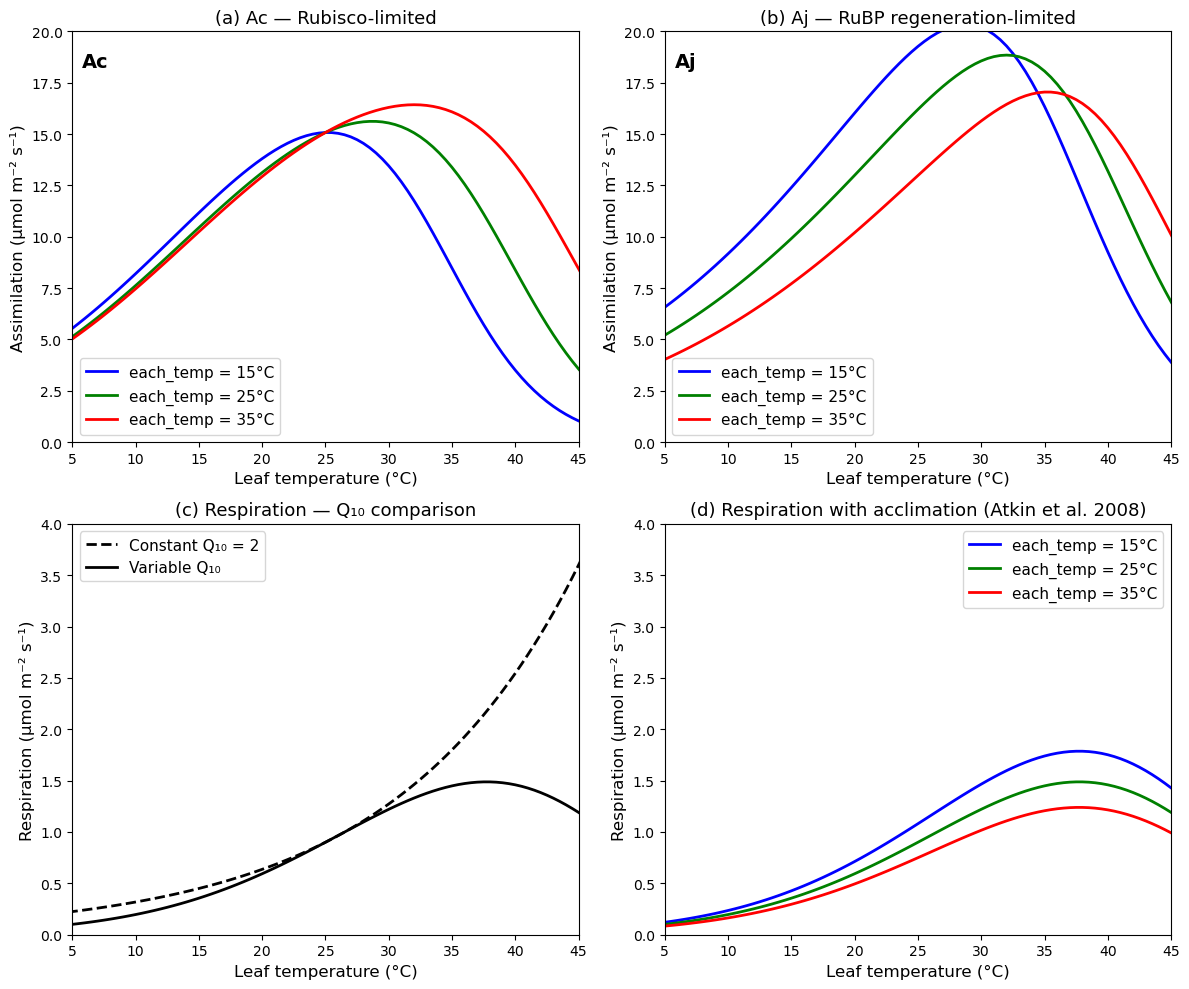

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Panel (a): Ac-limited assimilation
ax = axes[0, 0]
for each_temp, color, label in zip(growth_temps, colors, labels):
    ax.plot(
        leaf_temperatures,
        Ac_results[each_temp],
        color=color,
        linewidth=2,
        label=f"each_temp = {label}",
    )

ax.set_xlabel("Leaf temperature (°C)", fontsize=12)
ax.set_ylabel("Assimilation (µmol m⁻² s⁻¹)", fontsize=12)
ax.set_title("(a) Ac — Rubisco-limited", fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(5, 45)
ax.set_ylim(0, 20)
ax.axhline(y=0, color="gray", linewidth=0.5)
ax.text(
    0.02, 0.95, "Ac", transform=ax.transAxes, fontsize=14, fontweight="bold", va="top"
)

# Panel (b): Aj-limited assimilation
ax = axes[0, 1]
for each_temp, color, label in zip(growth_temps, colors, labels):
    ax.plot(
        leaf_temperatures,
        Aj_results[each_temp],
        color=color,
        linewidth=2,
        label=f"each_temp = {label}",
    )

ax.set_xlabel("Leaf temperature (°C)", fontsize=12)
ax.set_ylabel("Assimilation (µmol m⁻² s⁻¹)", fontsize=12)
ax.set_title("(b) Aj — RuBP regeneration-limited", fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(5, 45)
ax.set_ylim(0, 20)
ax.axhline(y=0, color="gray", linewidth=0.5)
ax.text(
    0.02, 0.95, "Aj", transform=ax.transAxes, fontsize=14, fontweight="bold", va="top"
)

# Panel (c): Respiration — constant vs variable Q10
ax = axes[1, 0]
ax.plot(
    leaf_temperatures,
    Rd_constant_Q10,
    color="black",
    linewidth=2,
    linestyle="--",
    label="Constant Q₁₀ = 2",
)
ax.plot(
    leaf_temperatures, Rd_variable_Q10, color="black", linewidth=2, label="Variable Q₁₀"
)
ax.set_xlabel("Leaf temperature (°C)", fontsize=12)
ax.set_ylabel("Respiration (µmol m⁻² s⁻¹)", fontsize=12)
ax.set_title("(c) Respiration — Q₁₀ comparison", fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(5, 45)
ax.set_ylim(0, 4)

# Panel (d): Respiration with acclimation
ax = axes[1, 1]
for each_temp, color, label in zip(growth_temps, colors, labels):
    ax.plot(
        leaf_temperatures,
        Rd_acclimated[each_temp],
        color=color,
        linewidth=2,
        label=f"each_temp = {label}",
    )

ax.set_xlabel("Leaf temperature (°C)", fontsize=12)
ax.set_ylabel("Respiration (µmol m⁻² s⁻¹)", fontsize=12)
ax.set_title("(d) Respiration with acclimation (Atkin et al. 2008)", fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(5, 45)
ax.set_ylim(0, 4)

plt.tight_layout()